# Phase 2 — Timepoint Mapping QC (Ingest-style) on GSE280305

## Goal
Quantify how well **states transfer across time** under different representations:
- Raw representation (e.g., `X_pca_raw` / `X_umap_raw`)
- Batch-corrected representation (e.g., `X_scanorama` / `X_umap_scanorama`)

This phase answers:
1) Are later cells explainable as “the same states, progressed”, or do they look **out-of-distribution (OOD)**?
2) Does Scanorama improve “transferability” without collapsing real time structure?

---

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import scgeo as sg

adata = sc.read_h5ad("data/GSE280305_paths_AB.h5ad")
adata.obs["timepoint"] = adata.obs["timepoint"].astype(str)

# Define reference/query
ref_mask = adata.obs["timepoint"] == "D8"
qry_mask = adata.obs["timepoint"].isin(["D11", "D14", "D21"])

print("Reference cells:", int(ref_mask.sum()))
print("Query cells:", int(qry_mask.sum()))

Reference cells: 13149
Query cells: 18456


## Inputs
- `data/GSE280305_scgeo_phase1_qc.h5ad` (or your latest Phase 1 output)
  - Must include: `obs['timepoint']`, `obs['leiden_raw']`, embeddings/representations for both raw & Scanorama.
  - Optional but recommended: `obs['fate_entropy']`, `obs['fate_margin']` from CellRank.




In [2]:
rep = "X_scanorama"
label_key = "leiden_raw"

X_ref = np.asarray(adata.obsm[rep][ref_mask], dtype=np.float32)

obs_ref = {
    label_key: adata.obs.loc[ref_mask, label_key].astype(str).to_numpy(),
    "timepoint": adata.obs.loc[ref_mask, "timepoint"].astype(str).to_numpy(),
    "obs_names": adata.obs_names[ref_mask].to_numpy(),
}

pool = sg.pp.build_reference_pool(
    X_ref,
    obs=obs_ref,
    label_key=label_key,
    n_neighbors=30,
    metric="euclidean",
    random_state=0,
)

### Checks to perform
- Confirm `timepoint ∈ {D8, D11, D14, D21}`
- Confirm `leiden_raw` exists
- Confirm both raw and Scanorama reps exist

In [3]:
sg.tl.map_query_to_ref_pool(
    adata,
    pool=pool,
    rep=rep,
    k=30,
    weight_method="inv",
    conf_method="entropy_margin",
    ood_method="distance",
    reject_conf=None,
    reject_ood=None,
    store_key="map_query_to_ref",
    pred_key="scgeo_pred",
    conf_key="scgeo_conf",
    conf_entropy_key="scgeo_conf_entropy",
    conf_margin_key="scgeo_conf_margin",
    ood_key="scgeo_ood",
    reject_key="scgeo_reject",
    return_probs=False,
)

In [4]:
[c for c in adata.obs.columns if c.startswith("scgeo")]

['scgeo_pred',
 'scgeo_conf_entropy',
 'scgeo_conf_margin',
 'scgeo_conf',
 'scgeo_ood']

In [5]:
adata.obs[[
    "timepoint",
    "leiden_raw",
    "scgeo_pred",
    "scgeo_conf",
    "scgeo_conf_entropy",
    "scgeo_conf_margin",
    "scgeo_ood",
]].head()

,timepoint,leiden_raw,scgeo_pred,scgeo_conf,scgeo_conf_entropy,scgeo_conf_margin,scgeo_ood
D8:GSM8594491:D8_count:AAAGCAACAGTCACTAx,D8,0,0,1.0,1.0,1.0,0.537609
D8:GSM8594491:D8_count:AAAGATGAGGTGGGTTx,D8,4,4,1.0,1.0,1.0,0.513715
D8:GSM8594491:D8_count:AAACGGGCAATGGAGCx,D8,8,8,1.0,1.0,1.0,0.294861
D8:GSM8594491:D8_count:AAACCTGAGTGTACCTx,D8,0,0,1.0,1.0,1.0,0.073748
D8:GSM8594491:D8_count:AAACCTGAGACACTAAx,D8,1,1,1.0,1.0,1.0,0.417530


In [6]:
adata.obs.groupby("timepoint")[["scgeo_conf", "scgeo_ood"]].describe()

scgeo_conf                                                        \
               count      mean           std       min       25%       50%   
timepoint                                                                    
D11           4513.0  0.899790  1.767291e-01  0.184497  0.890189  1.000000   
D14           5614.0  0.868915  2.009845e-01  0.237767  0.796349  1.000000   
D21           8329.0  0.795959  2.264239e-01  0.172244  0.591626  0.892628   
D8           13149.0  1.000000  9.364897e-11  1.000000  1.000000  1.000000   

                    scgeo_ood                                               \
           75%  max     count      mean       std  min       25%       50%   
timepoint                                                                    
D11        1.0  1.0    4513.0  0.501767  0.267587  0.0  0.319308  0.513756   
D14        1.0  1.0    5614.0  0.582443  0.261057  0.0  0.433674  0.602015   
D21        1.0  1.0    8329.0  0.665692  0.232438  0.0  0.519236  0.677561   
D8         1.0  1.0   13149.0  0.362461  0.219798  0.0  0.204398  0.358993   

                          
                75%  max  
timepoint                 
D11        0.685290  1.0  
D14        0.758076  1.0  
D21        0.840139  1.0  
D8         0.503470  1.0

In [7]:
conf_thr = 0.85
ood_thr = adata.obs["scgeo_ood"].quantile(0.95)

print("confidence threshold:", conf_thr)
print("OOD threshold:", ood_thr)

confidence threshold: 0.85
OOD threshold: 0.9999831319133411


In [8]:
adata.obs["scgeo_reject"] = (
    (adata.obs["scgeo_conf"] < conf_thr) |
    (adata.obs["scgeo_ood"] > ood_thr)
)

In [9]:
pd.crosstab(
    adata.obs["timepoint"],
    adata.obs["scgeo_reject"],
    normalize="index",
)

scgeo_reject,False,True
timepoint,,
D11,0.758476,0.241524
D14,0.679907,0.320093
D21,0.511466,0.488534
D8,0.993764,0.006236


In [10]:
pd.crosstab(
    adata.obs["timepoint"],
    adata.obs["scgeo_reject"],
    normalize="index",
)

scgeo_reject,False,True
timepoint,,
D11,0.758476,0.241524
D14,0.679907,0.320093
D21,0.511466,0.488534
D8,0.993764,0.006236


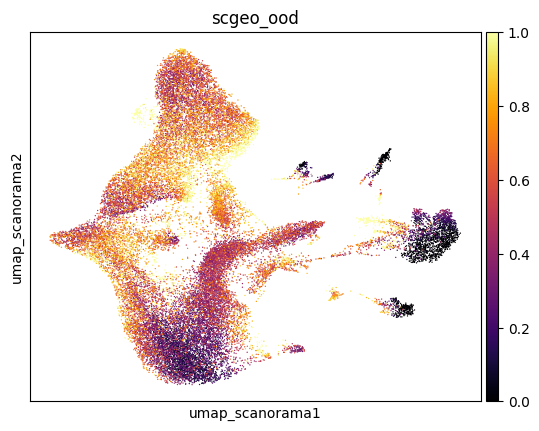

In [11]:
sc.pl.embedding(
    adata,
    basis="umap_scanorama",
    color=["scgeo_ood"],
    cmap="inferno",
)

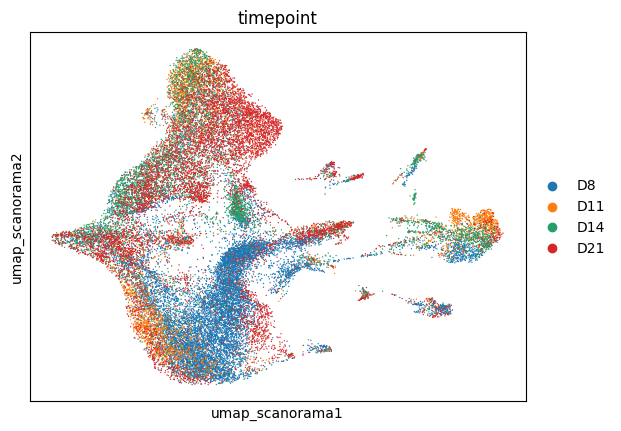

In [12]:
sc.pl.embedding(
    adata,
    basis="umap_scanorama",
    color=["timepoint"],
)

In [13]:
ref_mask = adata.obs["timepoint"].astype(str) == "D8"
qry_mask = adata.obs["timepoint"].astype(str).isin(["D11", "D14", "D21"])

ood_thr_ref = adata.obs.loc[ref_mask, "scgeo_ood"].quantile(0.95)
print("D8-based OOD threshold:", ood_thr_ref)

conf_thr = 0.85
adata.obs["scgeo_reject"] = (
    (adata.obs["scgeo_conf"] < conf_thr) |
    (adata.obs["scgeo_ood"] > ood_thr_ref)
)

pd.crosstab(
    adata.obs["timepoint"],
    adata.obs["scgeo_reject"],
    normalize="index",
)

D8-based OOD threshold: 0.7423340593802413


scgeo_reject,False,True
timepoint,,
D8,0.949958,0.050042
D11,0.679592,0.320408
D14,0.580335,0.419665
D21,0.392964,0.607036


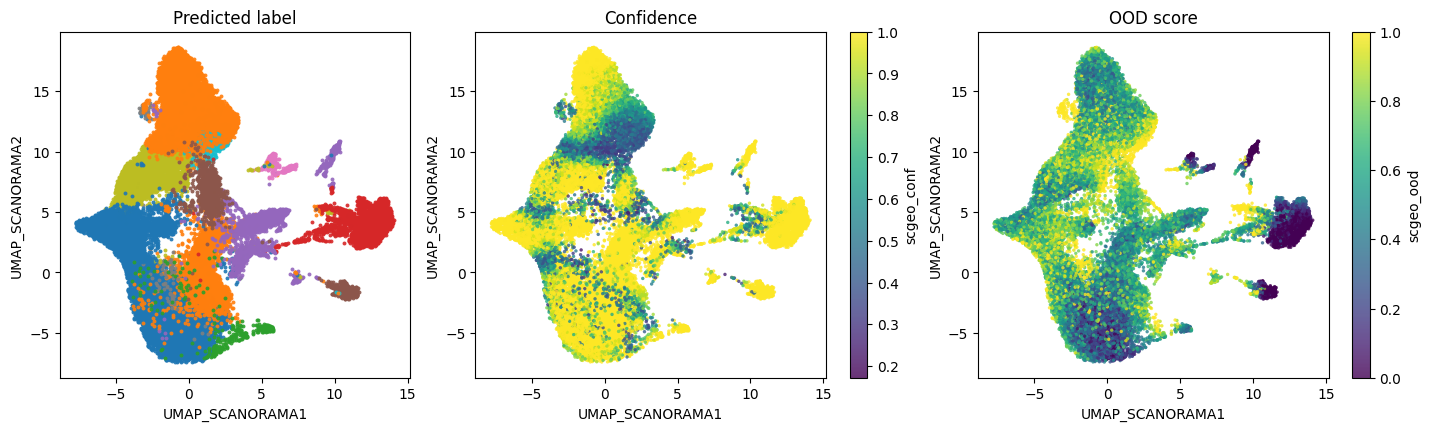

(<Figure size 1420x420 with 5 Axes>,
 array([<Axes: title={'center': 'Predicted label'}, xlabel='UMAP_SCANORAMA1', ylabel='UMAP_SCANORAMA2'>,
        <Axes: title={'center': 'Confidence'}, xlabel='UMAP_SCANORAMA1', ylabel='UMAP_SCANORAMA2'>,
        <Axes: title={'center': 'OOD score'}, xlabel='UMAP_SCANORAMA1', ylabel='UMAP_SCANORAMA2'>],
       dtype=object))

In [14]:

sg.pl.mapping_qc_panel(
    adata,
    pred_key="scgeo_pred",
    conf_key="scgeo_conf",
    ood_key="scgeo_ood",
    basis="umap_scanorama",
    show=True,
)

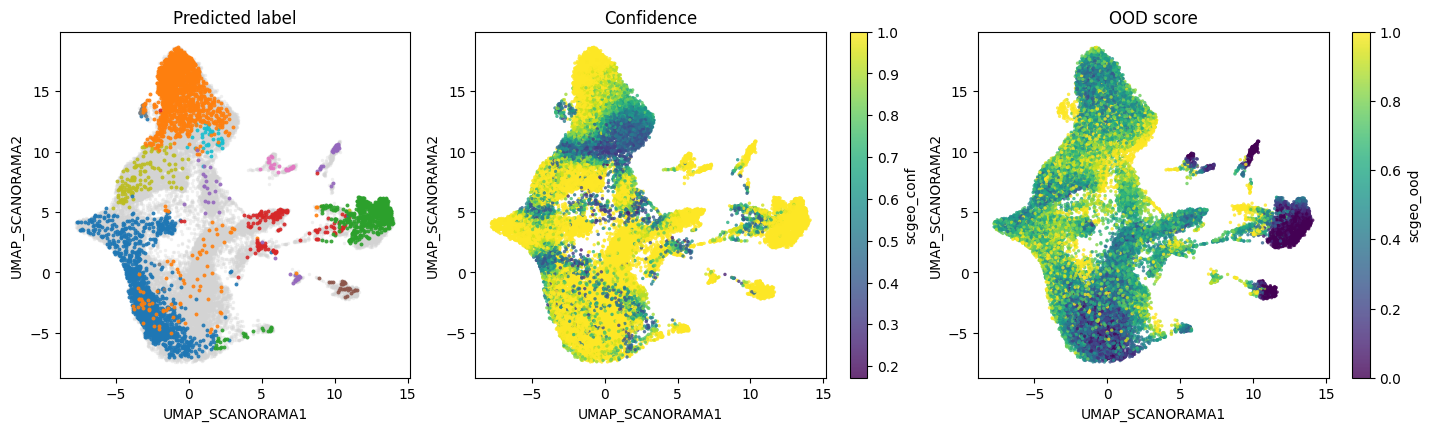

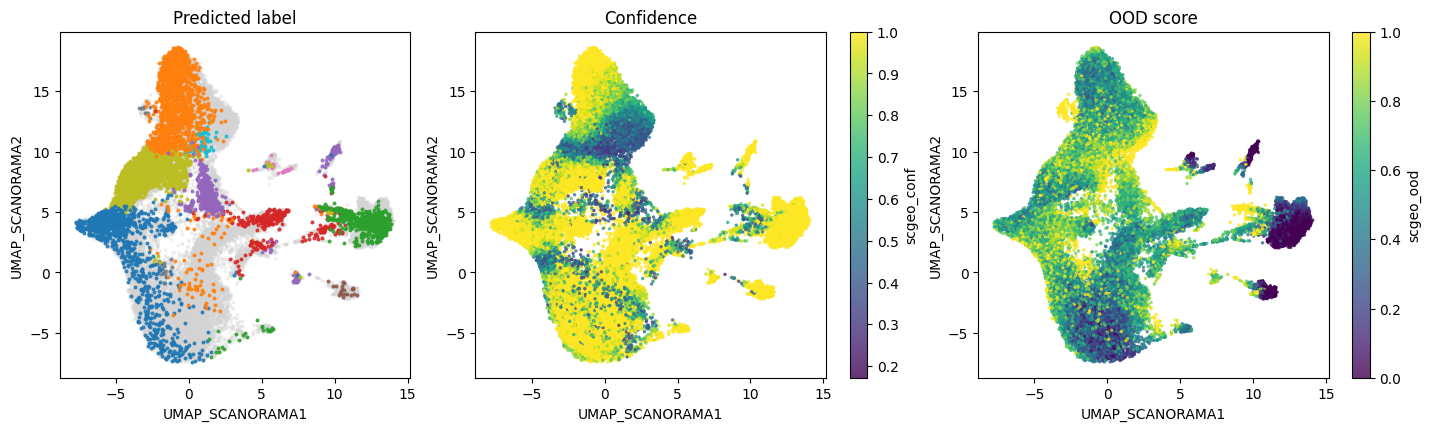

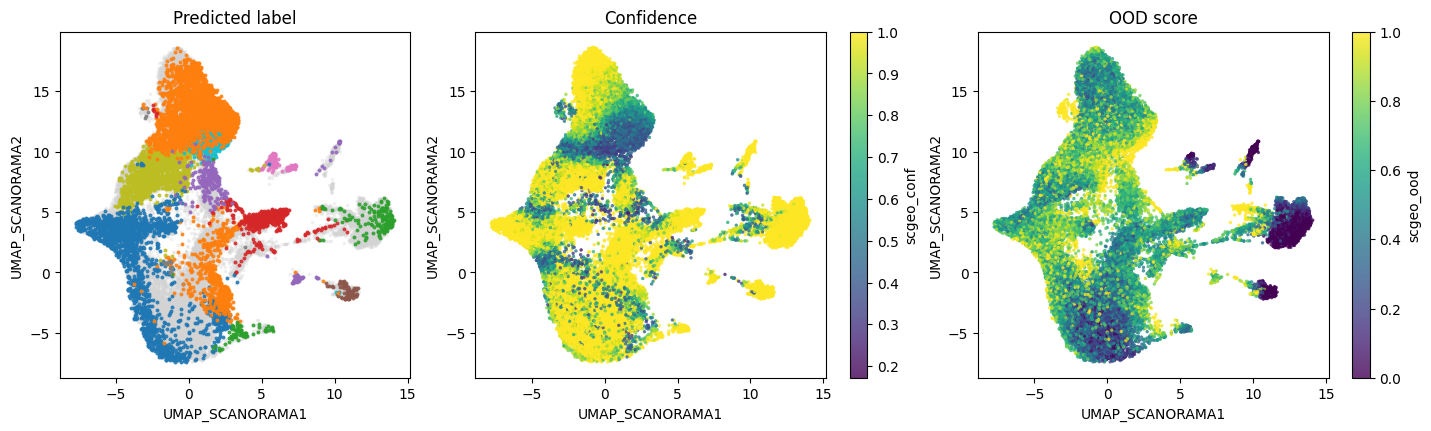

In [15]:
for tp in ["D11", "D14", "D21"]:
    sg.pl.mapping_qc_panel(
        adata,
        pred_key="scgeo_pred",
        conf_key="scgeo_conf",
        ood_key="scgeo_ood",
        basis="umap_scanorama",
        condition_key="timepoint",
        query_value=tp,
        show_ref_as_grey=True,
        show=True,
    )

In [16]:
adata_vel=sc.read_h5ad("data/pathC_alignment.h5ad")

In [17]:
adata.obs["alignment_group"] = adata_vel.obs.loc[adata.obs_names, "alignment_group"].astype(str).values

In [18]:
adata.obs.groupby("alignment_group")["scgeo_ood"].describe()
adata.obs.groupby("alignment_group")["scgeo_conf"].describe()

,count,mean,std,min,25%,50%,75%,max
alignment_group,,,,,,,,
aligned,13131.0,0.857372,0.215256,0.172244,0.719334,1.0,1.0,1.0
discordant,13649.0,0.947838,0.139016,0.184497,1.000000,1.0,1.0,1.0
other,4825.0,0.937242,0.134888,0.264734,0.941447,1.0,1.0,1.0


In [19]:
pd.crosstab(
    adata.obs["leiden_raw"],
    adata.obs["scgeo_pred"],
    normalize="index"
)

scgeo_pred,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
leiden_raw,,,,,,,,,,,,,,,,
0,0.998657,0.000959,0.000000,0.000000,0.000192,0.000000,0.000000,0.000000,0.000192,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.002550,0.995154,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.002295,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.000000,0.000000,0.893078,0.006194,0.007272,0.088877,0.000000,0.000000,0.000000,0.003232,0.000000,0.000269,0.000000,0.000808,0.000269,0.000000
3,0.000000,0.000000,0.011435,0.177530,0.000858,0.806461,0.000000,0.000286,0.000000,0.002573,0.000000,0.000572,0.000000,0.000000,0.000286,0.000000
4,0.013527,0.001932,0.012560,0.000000,0.967794,0.002899,0.000000,0.000000,0.000644,0.000322,0.000000,0.000322,0.000000,0.000000,0.000000,0.000000
5,0.000000,0.000000,0.000348,0.000000,0.000000,0.993046,0.000000,0.000000,0.004868,0.000695,0.000000,0.000000,0.001043,0.000000,0.000000,0.000000
6,0.915341,0.030272,0.000000,0.000000,0.014879,0.000000,0.030272,0.000000,0.001026,0.000000,0.008209,0.000000,0.000000,0.000000,0.000000,0.000000
7,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.996115,0.000000,0.000000,0.000000,0.003885,0.000000,0.000000,0.000000,0.000000
8,0.001791,0.017313,0.002388,0.000000,0.003582,0.000597,0.000000,0.000000,0.952836,0.016716,0.000000,0.003582,0.001194,0.000000,0.000000,0.000000


In [20]:
adata.obs.groupby("leiden_raw")["scgeo_ood"].mean().sort_values()

/tmp/ipykernel_6945/1416132790.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs.groupby("leiden_raw")["scgeo_ood"].mean().sort_values()


leiden_raw
7     0.111491
13    0.163045
0     0.261855
14    0.288600
12    0.414398
1     0.420789
6     0.515057
5     0.548251
8     0.549889
10    0.609982
2     0.657437
4     0.657934
3     0.682884
9     0.702898
11    0.716321
15    0.918825
Name: scgeo_ood, dtype: float64

In [21]:
pd.crosstab(
    adata.obs["leiden_raw"],
    adata.obs["alignment_group"],
    normalize="index"
)

alignment_group,aligned,discordant,other
leiden_raw,,,
0,0.0,1.0,0.0
1,1.0,0.0,0.0
2,1.0,0.0,0.0
3,1.0,0.0,0.0
4,0.0,1.0,0.0
5,0.0,0.0,1.0
6,0.0,0.0,1.0
7,0.0,1.0,0.0
8,1.0,0.0,0.0


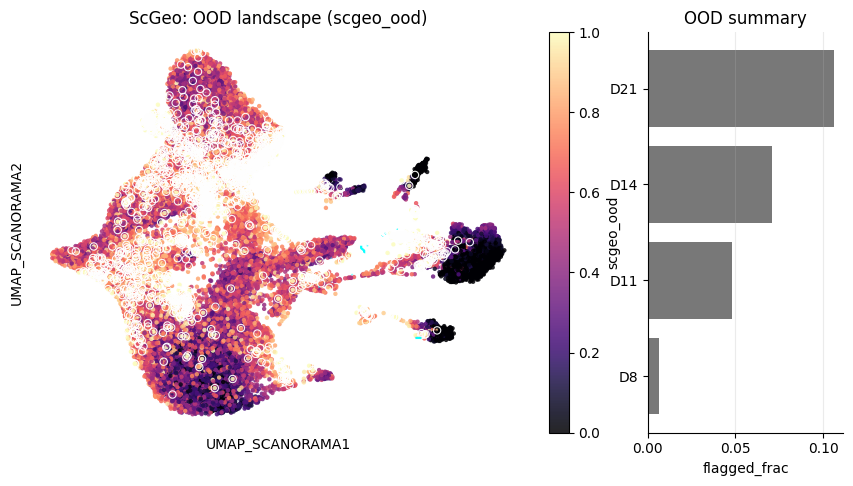

(<Figure size 1050x520 with 3 Axes>,
 (<Axes: title={'center': 'ScGeo: OOD landscape (scgeo_ood)'}, xlabel='UMAP_SCANORAMA1', ylabel='UMAP_SCANORAMA2'>,
  <Axes: title={'center': 'OOD summary'}, xlabel='flagged_frac'>))

In [22]:
sg.pl.ood_landscape(
    adata,
    ood_key="scgeo_ood",
    basis="umap_scanorama",
    threshold=None,
    groupby="timepoint",
)

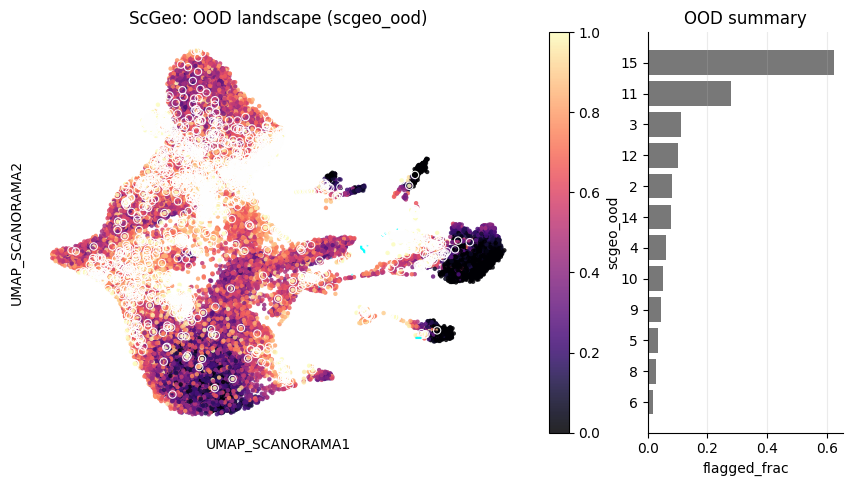

(<Figure size 1050x520 with 3 Axes>,
 (<Axes: title={'center': 'ScGeo: OOD landscape (scgeo_ood)'}, xlabel='UMAP_SCANORAMA1', ylabel='UMAP_SCANORAMA2'>,
  <Axes: title={'center': 'OOD summary'}, xlabel='flagged_frac'>))

In [23]:
sg.pl.ood_landscape(
    adata,
    ood_key="scgeo_ood",
    basis="umap_scanorama",
    threshold=None,
    groupby="leiden_raw",
    top_n_groups=12,
)

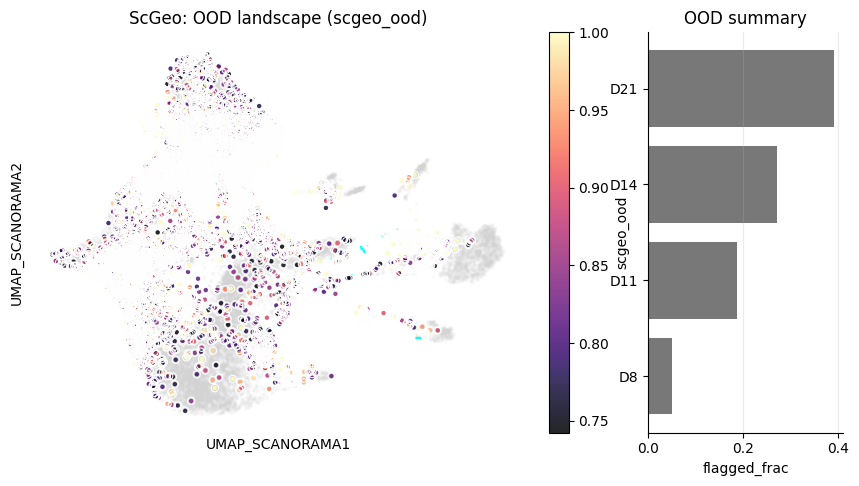

(<Figure size 1050x520 with 3 Axes>,
 (<Axes: title={'center': 'ScGeo: OOD landscape (scgeo_ood)'}, xlabel='UMAP_SCANORAMA1', ylabel='UMAP_SCANORAMA2'>,
  <Axes: title={'center': 'OOD summary'}, xlabel='flagged_frac'>))

In [24]:
ood_thr = 0.7423340593802413

sg.pl.ood_landscape(
    adata,
    ood_key="scgeo_ood",
    basis="umap_scanorama",
    threshold=ood_thr,
    show_only_flagged=True,
    groupby="timepoint",
)

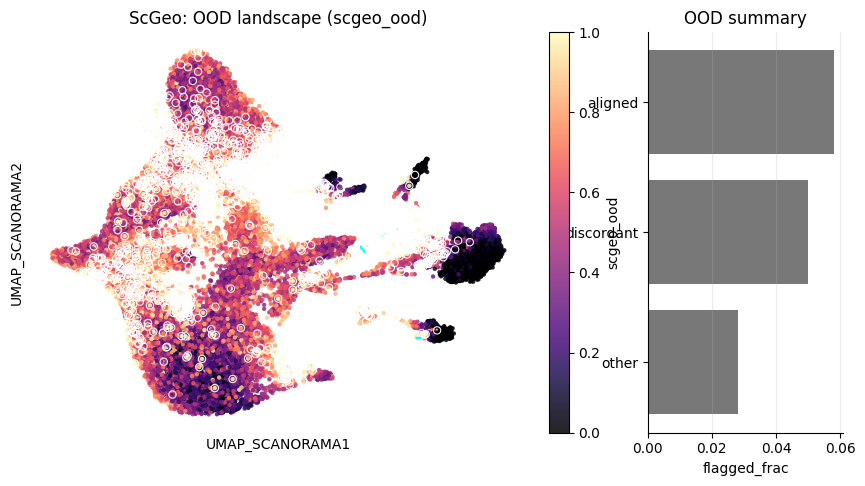

(<Figure size 1050x520 with 3 Axes>,
 (<Axes: title={'center': 'ScGeo: OOD landscape (scgeo_ood)'}, xlabel='UMAP_SCANORAMA1', ylabel='UMAP_SCANORAMA2'>,
  <Axes: title={'center': 'OOD summary'}, xlabel='flagged_frac'>))

In [25]:
sg.pl.ood_landscape(
    adata,
    ood_key="scgeo_ood",
    basis="umap_scanorama",
    groupby="alignment_group",
)

In [26]:
adata.obs.groupby(["alignment_group", "timepoint"])["scgeo_ood"].mean().unstack()

/tmp/ipykernel_6945/1353782406.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs.groupby(["alignment_group", "timepoint"])["scgeo_ood"].mean().unstack()


timepoint,D8,D11,D14,D21
alignment_group,,,,
aligned,0.426398,0.627599,0.638929,0.675074
discordant,0.309092,0.371846,0.543737,0.672702
other,0.469923,0.537138,0.557251,0.558910


In [27]:
adata.write("data/GSE280305_for_Ref.h5ad")